# Olist 공동집하거점 PPT 구성안

`공동집하거점_무가중_수정.ipynb`를 중심으로 하되, `review_score_logistics_correlation.ipynb`와 `population_adjusted_olist_usage_infrastructure.ipynb`에서 공동집하거점 분석으로 이어지는 문제의식을 먼저 보여주는 14장 발표 구성안입니다.

발표 흐름은 다음과 같습니다.

1. 리뷰와 배송 성과의 연결을 확인했다.
2. 인구 대비 Olist 이용량과 배송 부담을 함께 보니 북부·북동부가 구조적으로 불리했다.
3. 그래서 북부·북동부의 A그룹 주를 대상으로 공동집하거점 후보를 찾았다.
4. 최종 후보 주/도시, 지도 시각화, 기존 물류허브 추정 위치와의 관계를 제시한다.

주의: 아래 결과는 인프라 설치의 확정 인과효과가 아니라, Olist 관측 데이터와 벤치마크 기반 시뮬레이션으로 만든 의사결정 근거입니다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'notebooks').exists()), Path.cwd())
OUTPUT_DIR = BASE_DIR / 'notebooks' / 'Distribution_hub' / 'SG' / 'Logistics_folder' / 'outputs'
FIG_DIR = OUTPUT_DIR / 'ppt_figures'
FIG_DIR.mkdir(exist_ok=True)

def read_output(name):
    return pd.read_csv(OUTPUT_DIR / name)

review_corr = read_output('review_score_numeric_correlations.csv')
review_region = read_output('review_score_region_summary.csv')
region_usage = read_output('population_adjusted_region_usage.csv')
infra_candidates = read_output('infrastructure_investment_candidates.csv')
hub_candidates = read_output('unweighted_dual_side_micro_hub_candidates.csv')
customer_points = read_output('unweighted_dual_side_hub_customer_points.csv')
final_recovery = read_output('unweighted_final_recovery_scenario_table.csv')
hub_existing = read_output('hub_vs_existing_hub_comparison.csv')
existing_hubs = read_output('seller_handover_existing_hub_estimates.csv')

REGION_ORDER = ['남동부', '남부', '중서부', '북동부', '북부']
REGION_COLORS = {'남동부': '#4C78A8', '남부': '#59A14F', '중서부': '#F28E2B', '북동부': '#E15759', '북부': '#B07AA1'}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'saved: {path}')

def annotate_points(ax, df, x, y, label, dx=0.3, dy=0.2, size=9):
    for _, row in df.iterrows():
        ax.text(row[x] + dx, row[y] + dy, str(row[label]), fontsize=size, weight='bold')

print('Loaded:', OUTPUT_DIR)
print('hub candidates:', len(hub_candidates), '| existing hub estimates:', len(existing_hubs))

Loaded: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs
hub candidates: 13 | existing hub estimates: 20


## Slide 1. 분석이 시작된 질문

**제목 제안**: `왜 공동집하거점 분석까지 가게 되었나`

**넣을 내용**

- Olist 데이터에서 고객 경험 저하가 단순히 상품/가격 문제가 아니라 배송 성과와 연결되는지 먼저 확인했다.
- 그다음 지역별로 Olist 이용량이 인구 규모에 비해 충분한지, 배송 부담이 큰 지역이 어디인지 보았다.
- 그 결과 북부·북동부 일부 주에서 `낮은 이용 침투도 + 긴 배송일/높은 지연율`이 함께 나타났다.
- 따라서 공동집하거점은 갑자기 나온 아이디어가 아니라, 앞선 분석에서 발견한 지역 물류 접근성 문제를 해결하기 위한 후속 분석이다.

**시각화**: 분석 흐름을 한 장짜리 프로세스로 제시.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide01_analysis_flow.png


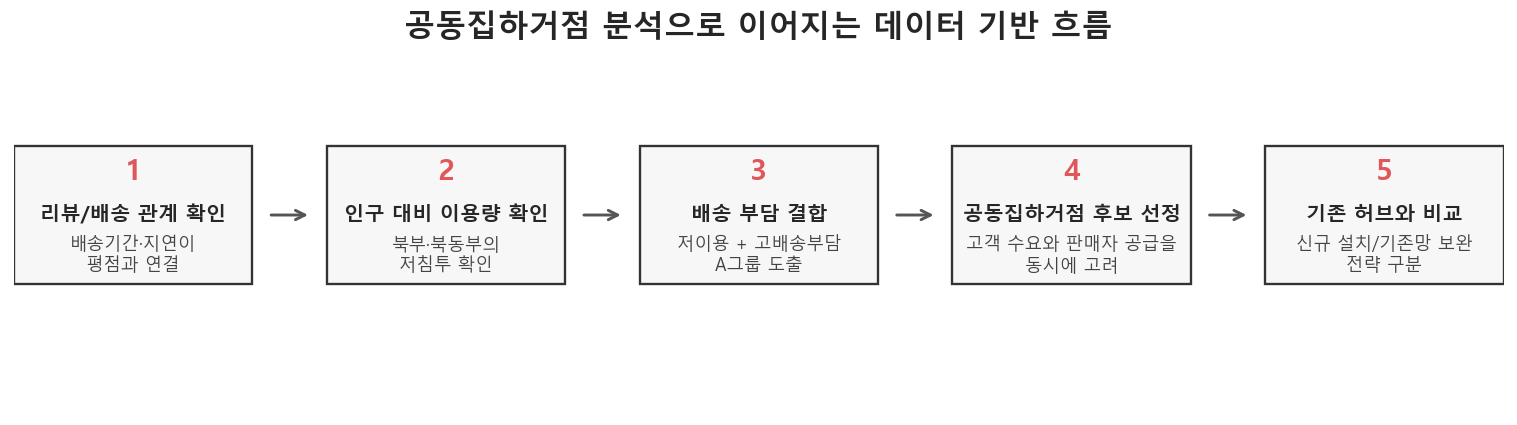

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
steps = [
    ('1', '리뷰/배송 관계 확인', '배송기간·지연이\n평점과 연결'),
    ('2', '인구 대비 이용량 확인', '북부·북동부의\n저침투 확인'),
    ('3', '배송 부담 결합', '저이용 + 고배송부담\nA그룹 도출'),
    ('4', '공동집하거점 후보 선정', '고객 수요와 판매자 공급을\n동시에 고려'),
    ('5', '기존 허브와 비교', '신규 설치/기존망 보완\n전략 구분')
]
xs = np.linspace(0.08, 0.92, len(steps))
for i, (num, title, desc) in enumerate(steps):
    x = xs[i]
    ax.add_patch(plt.Rectangle((x - 0.08, 0.35), 0.16, 0.38, facecolor='#F7F7F7', edgecolor='#333333', linewidth=1.2))
    ax.text(x, 0.66, num, ha='center', va='center', fontsize=15, weight='bold', color='#E15759')
    ax.text(x, 0.54, title, ha='center', va='center', fontsize=10.5, weight='bold')
    ax.text(x, 0.43, desc, ha='center', va='center', fontsize=9, color='#444444')
    if i < len(steps) - 1:
        ax.annotate('', xy=(xs[i+1] - 0.09, 0.54), xytext=(x + 0.09, 0.54), arrowprops=dict(arrowstyle='->', lw=1.5, color='#555555'))
ax.set_title('공동집하거점 분석으로 이어지는 데이터 기반 흐름', fontsize=16, weight='bold')
savefig('slide01_analysis_flow.png')
plt.show()

## Slide 2. 고객 경험 문제는 배송 변수와 먼저 연결된다

**제목 제안**: `리뷰 점수는 배송 성과와 더 강하게 연결됨`

**넣을 내용**

- `review_score_logistics_correlation.ipynb`에서는 리뷰 점수와 주요 수치형 변수의 상관을 확인했다.
- Spearman 상관 상위 변수 대부분이 배송 관련 변수였다.
- 특히 배송 소요일, 배송사 인계 후 고객 수령까지의 기간, 예상 배송일 초과가 평점 하락과 연결된다.
- 단, 이 슬라이드는 인과효과 주장이 아니라 “물류 성과가 고객 경험과 연결되어 있다”는 문제 제기다.

**시각화**: 리뷰 점수와의 절대 Spearman 상관 상위 변수.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide02_review_logistics_correlation.png


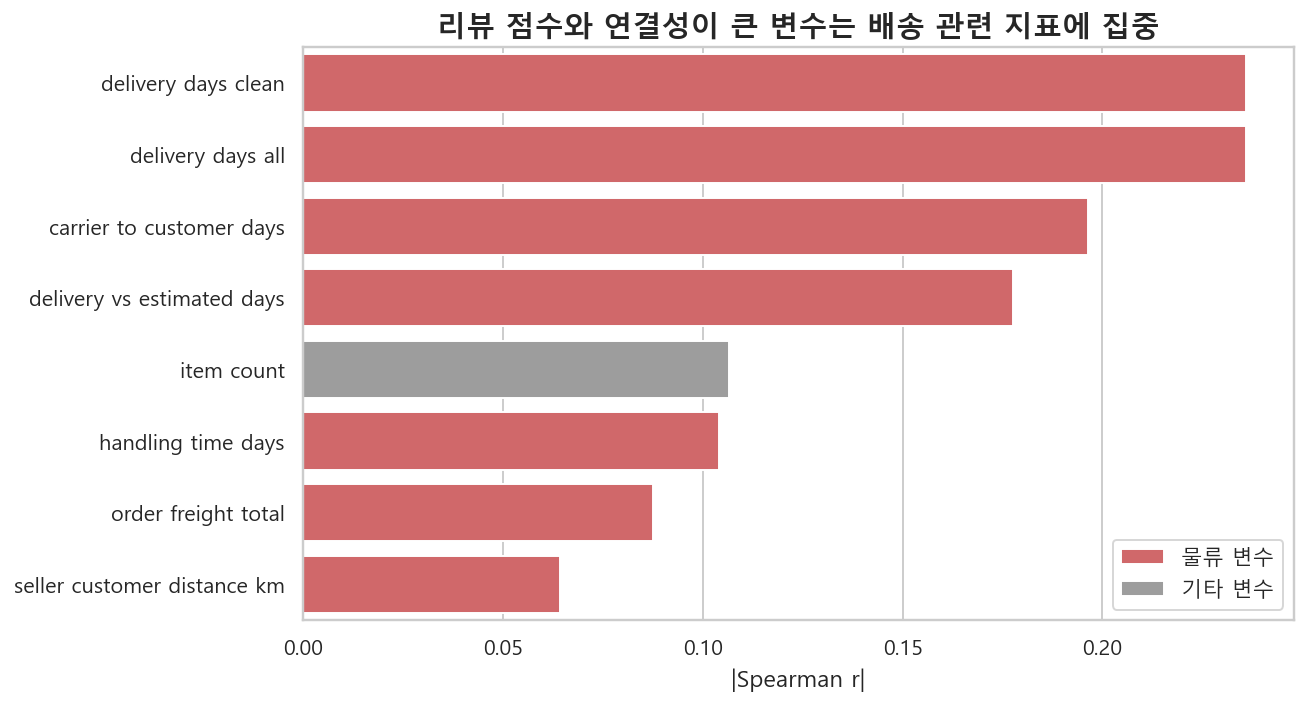

In [3]:
corr_top = review_corr.sort_values('abs_spearman_r', ascending=False).head(8).copy()
corr_top['변수'] = corr_top['column'].str.replace('_', ' ')
corr_top['구분'] = np.where(corr_top['is_logistics'].astype(str).str.lower().eq('true'), '물류 변수', '기타 변수')

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(data=corr_top, y='변수', x='abs_spearman_r', hue='구분', palette={'물류 변수': '#E15759', '기타 변수': '#9D9D9D'}, ax=ax)
ax.set_title('리뷰 점수와 연결성이 큰 변수는 배송 관련 지표에 집중', fontsize=15, weight='bold')
ax.set_xlabel('|Spearman r|')
ax.set_ylabel('')
ax.legend(title='')
savefig('slide02_review_logistics_correlation.png')
plt.show()

## Slide 3. 지역별 평점 차이는 물류 접근성 문제의 신호다

**제목 제안**: `북부·북동부 고객 경험이 상대적으로 낮음`

**넣을 내용**

- 권역별 평균 리뷰 점수는 북부와 북동부에서 낮게 나타난다.
- 다만 효과크기는 작기 때문에, 지역 그 자체가 평점을 결정한다고 말하기보다 지역별 물류 접근성 차이가 고객 경험에 반영될 가능성으로 해석한다.
- 이 결과는 다음 슬라이드의 인구 대비 이용량/배송 부담 분석으로 넘어가는 연결고리다.

**시각화**: 권역별 평균 리뷰 점수와 전체 평균 대비 차이.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide03_region_review_gap.png


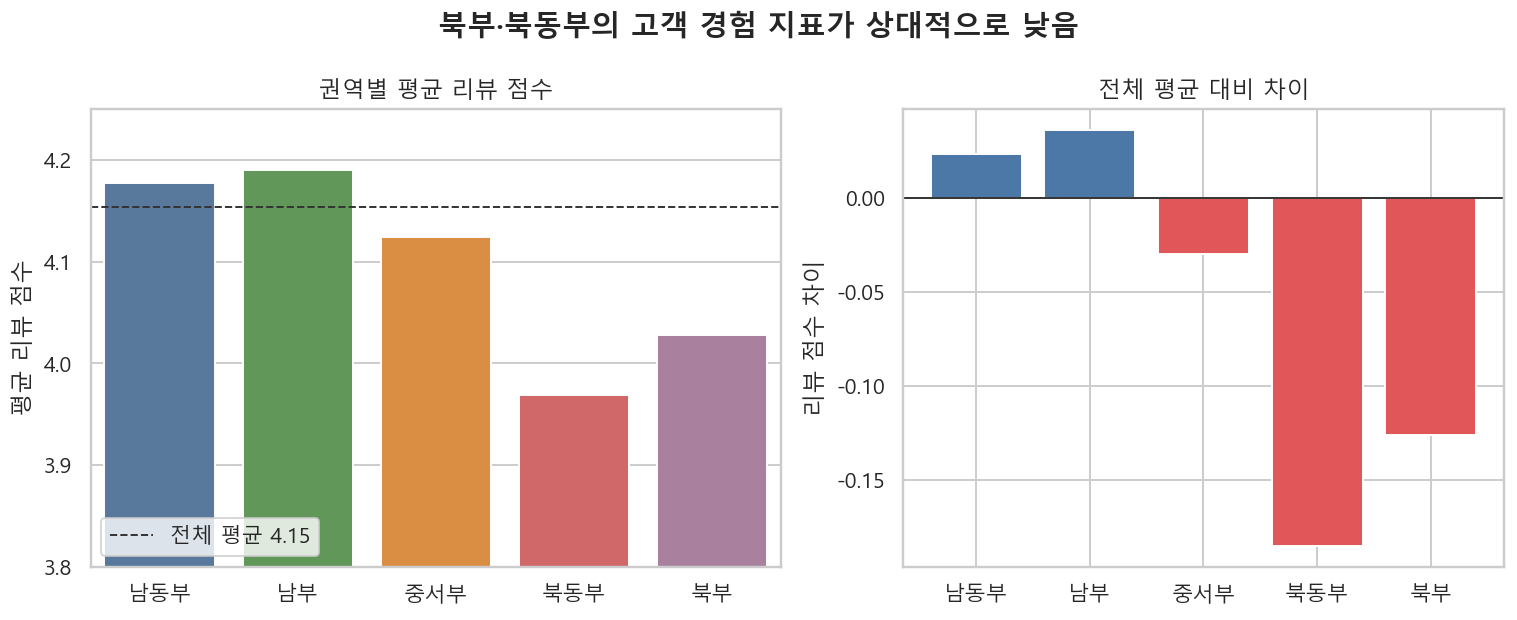

In [4]:
rr = review_region.copy()
rr['region'] = pd.Categorical(rr['region'], REGION_ORDER, ordered=True)
rr = rr.sort_values('region')
overall = np.average(rr['mean_review'], weights=rr['n'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1.15, 1]})
sns.barplot(data=rr, x='region', y='mean_review', palette=[REGION_COLORS[r] for r in rr['region']], ax=axes[0])
axes[0].axhline(overall, color='#333333', linestyle='--', linewidth=1, label=f'전체 평균 {overall:.2f}')
axes[0].set_title('권역별 평균 리뷰 점수')
axes[0].set_xlabel('')
axes[0].set_ylabel('평균 리뷰 점수')
axes[0].set_ylim(3.8, 4.25)
axes[0].legend(loc='lower left')

colors = ['#E15759' if v < 0 else '#4C78A8' for v in rr['mean_diff_from_overall']]
axes[1].bar(rr['region'].astype(str), rr['mean_diff_from_overall'], color=colors)
axes[1].axhline(0, color='#333333', linewidth=1)
axes[1].set_title('전체 평균 대비 차이')
axes[1].set_xlabel('')
axes[1].set_ylabel('리뷰 점수 차이')
fig.suptitle('북부·북동부의 고객 경험 지표가 상대적으로 낮음', fontsize=15, weight='bold')
savefig('slide03_region_review_gap.png')
plt.show()

## Slide 4. 단순 평점이 아니라 이용 침투도와 배송 부담을 함께 봤다

**제목 제안**: `북부·북동부는 낮은 이용량과 긴 배송일이 동시에 나타남`

**넣을 내용**

- `population_adjusted_olist_usage_infrastructure.ipynb`에서는 권역/주별 인구 대비 Olist 이용량을 계산했다.
- 남동부·남부는 인구 10만 명당 주문 수가 높고 배송일이 짧다.
- 북부·북동부는 인구 대비 주문 수가 낮고 평균 배송일이 길다.
- 그래서 공동집하거점 필요성은 “평점이 낮다”가 아니라 “이용 침투가 낮고 물류 부담이 큰 시장이 있다”는 근거에서 출발한다.

**시각화**: 권역별 주문 침투도와 평균 배송일.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide04_region_usage_delivery.png


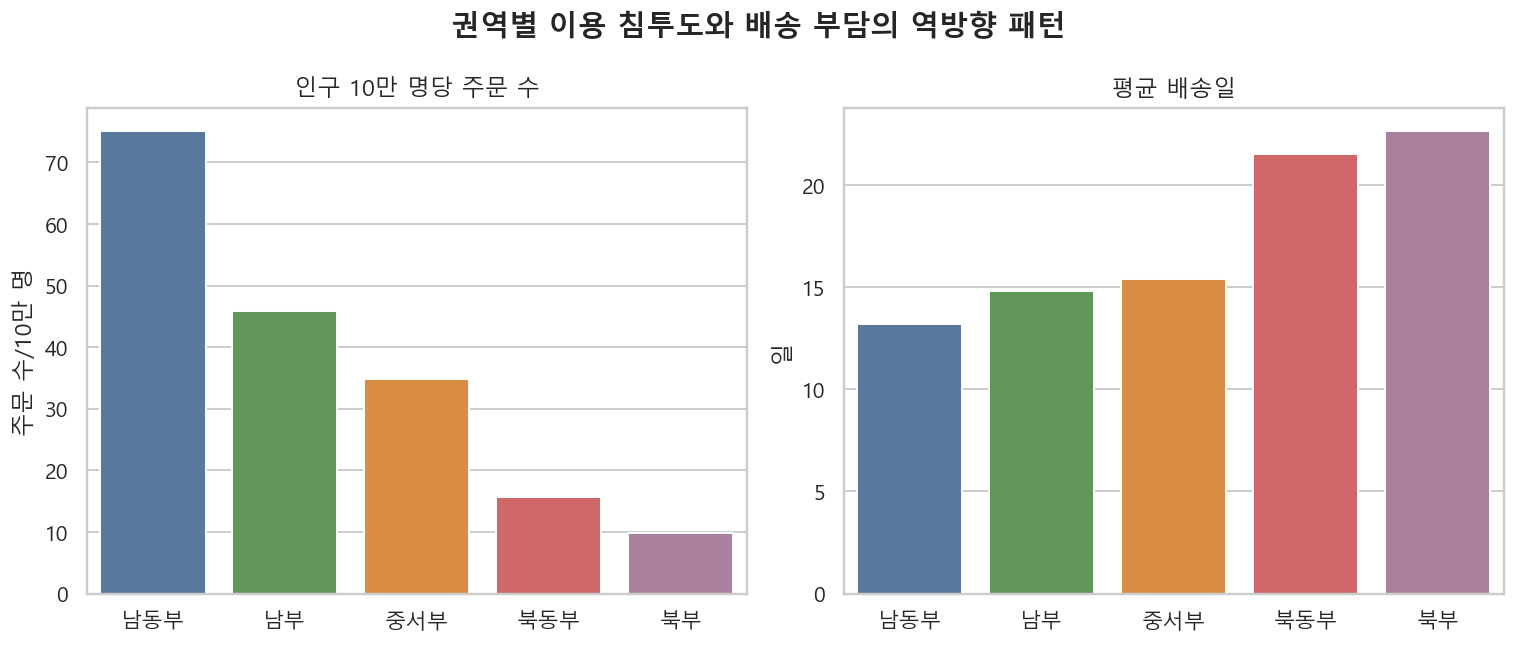

In [5]:
ru = region_usage.copy()
ru['region'] = pd.Categorical(ru['region'], REGION_ORDER, ordered=True)
ru = ru.sort_values('region')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
sns.barplot(data=ru, x='region', y='orders_per_100k', palette=[REGION_COLORS[r] for r in ru['region']], ax=axes[0])
axes[0].set_title('인구 10만 명당 주문 수')
axes[0].set_xlabel('')
axes[0].set_ylabel('주문 수/10만 명')

sns.barplot(data=ru, x='region', y='avg_delivery_days', palette=[REGION_COLORS[r] for r in ru['region']], ax=axes[1])
axes[1].set_title('평균 배송일')
axes[1].set_xlabel('')
axes[1].set_ylabel('일')
fig.suptitle('권역별 이용 침투도와 배송 부담의 역방향 패턴', fontsize=15, weight='bold')
savefig('slide04_region_usage_delivery.png')
plt.show()

## Slide 5. 왜 북부·북동부인가

**제목 제안**: `저이용·고배송부담 A그룹이 북부·북동부에 집중`

**넣을 내용**

- md 보고서의 핵심 기준은 두 가지다: `인구 대비 이용량이 낮은가`, `동시에 배송 부담이 큰가`.
- 이 기준으로 만든 `A_infra_investment_candidate`는 공동집하거점 등 인프라 투자 우선 검토군이다.
- 상위 A그룹은 AL, MA, RR, SE, CE, PA, PI, PB 등 북부·북동부에 집중된다.
- 따라서 “북부·북동부에 설치해야 한다”는 주장은 지역 선호가 아니라 데이터에서 관측된 저침투/고배송부담 조합에 근거한다.

**시각화**: 주별 주문 침투도와 배송일 산점도, A그룹 강조.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide05_why_north_northeast.png


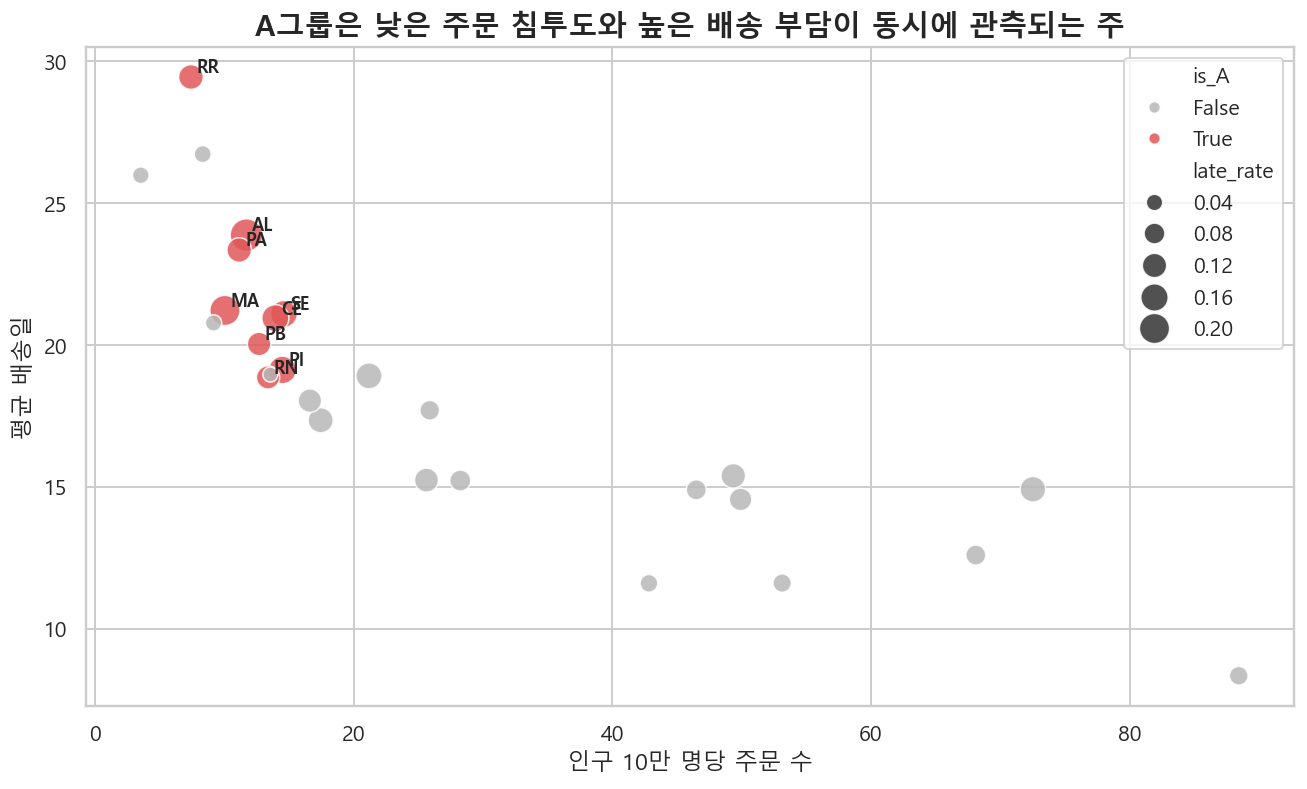

In [6]:
ic = infra_candidates.copy()
ic['is_A'] = ic['candidate_group'].str.startswith('A')

fig, ax = plt.subplots(figsize=(9.5, 5.8))
sns.scatterplot(data=ic, x='orders_per_100k', y='avg_delivery_days', hue='is_A', size='late_rate', sizes=(60, 280), palette={True: '#E15759', False: '#B8B8B8'}, alpha=0.85, edgecolor='white', linewidth=0.8, ax=ax)
annotate_points(ax, ic[ic['is_A']], 'orders_per_100k', 'avg_delivery_days', 'uf', dx=0.45, dy=0.15, size=9)
ax.set_title('A그룹은 낮은 주문 침투도와 높은 배송 부담이 동시에 관측되는 주', fontsize=15, weight='bold')
ax.set_xlabel('인구 10만 명당 주문 수')
ax.set_ylabel('평균 배송일')
ax.legend(title='', loc='upper right')
savefig('slide05_why_north_northeast.png')
plt.show()

## Slide 6. 인프라 후보 점수는 저침투와 배송 부담의 결합이다

**제목 제안**: `인프라 우선순위 = 저이용 60% + 배송 부담 40%`

**넣을 내용**

- 분석에서는 `infra_priority_score = 0.60 * under_usage_score + 0.40 * delivery_burden_score`로 후보군을 나눴다.
- `under_usage_score`는 인구 대비 이용량이 낮은 정도, `delivery_burden_score`는 평균 배송일·지연율·예상 배송일 초과를 반영한다.
- 공동집하거점은 이 A그룹 안에서 구체적인 도시/우편번호 후보를 찾는 다음 단계다.

**시각화**: A그룹 주의 인프라 점수 구성.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide06_infra_priority_components.png


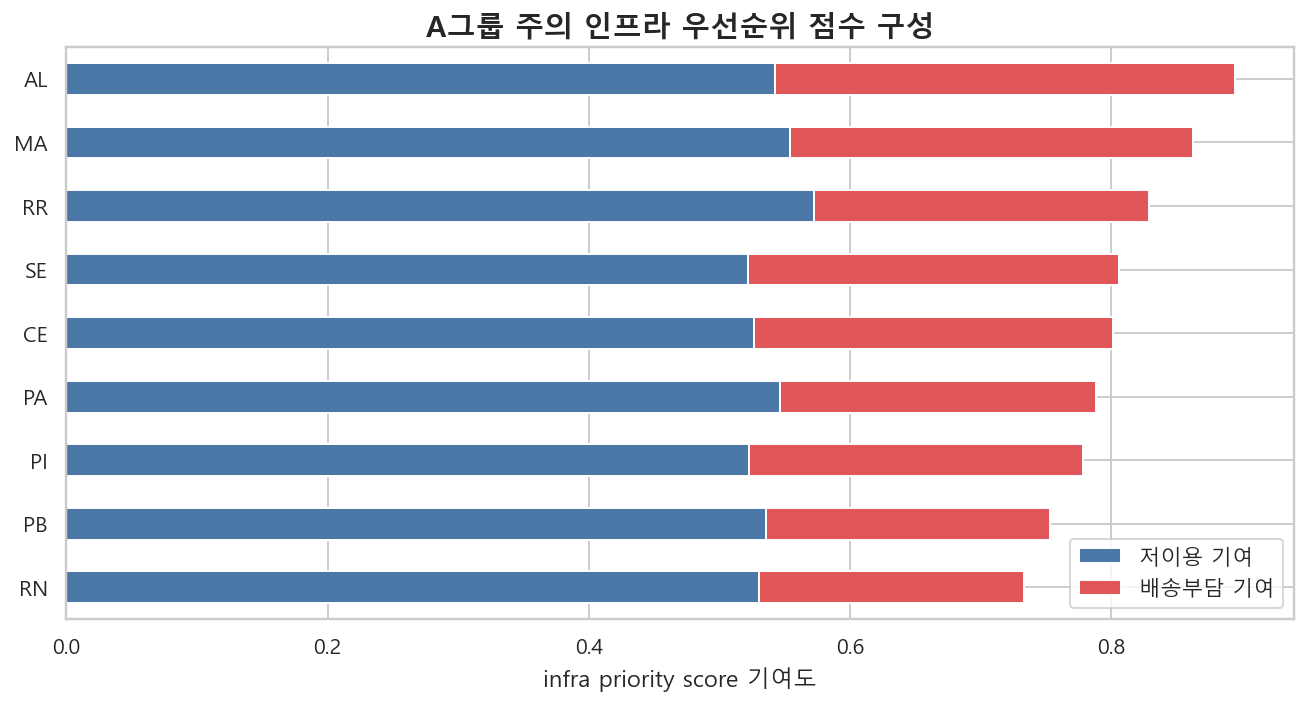

In [7]:
a_states = ic[ic['is_A']].sort_values('infra_priority_score', ascending=False).copy()
a_states['저이용 기여'] = 0.60 * a_states['under_usage_score']
a_states['배송부담 기여'] = 0.40 * a_states['delivery_burden_score']
plot = a_states[['uf', '저이용 기여', '배송부담 기여']].set_index('uf')

fig, ax = plt.subplots(figsize=(9.5, 5.2))
plot.plot(kind='barh', stacked=True, color=['#4C78A8', '#E15759'], ax=ax)
ax.invert_yaxis()
ax.set_title('A그룹 주의 인프라 우선순위 점수 구성', fontsize=15, weight='bold')
ax.set_xlabel('infra priority score 기여도')
ax.set_ylabel('')
ax.legend(title='')
savefig('slide06_infra_priority_components.png')
plt.show()

## Slide 7. 그래서 분석 단위를 주에서 거점 후보로 좁혔다

**제목 제안**: `A그룹 내부에서 실제 후보 도시를 찾는 방식`

**넣을 내용**

- 주 단위 A그룹은 “어느 지역권을 볼 것인가”를 정해준다.
- `공동집하거점_무가중_수정.ipynb`에서는 A그룹 주 안에서 고객 수요점과 판매자 공급점을 함께 사용했다.
- 무가중 K-Means 기반 후보를 만들고, 실제 고객/판매자 좌표와 가까운 도시/우편번호로 보정했다.
- 후보 점수는 고객 수요, 판매자 공급, 배송 부담, 시장 미침투도를 함께 본다.

**시각화**: 주 단위 문제에서 거점 후보로 좁히는 분석 로직.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide07_state_to_hub_logic.png


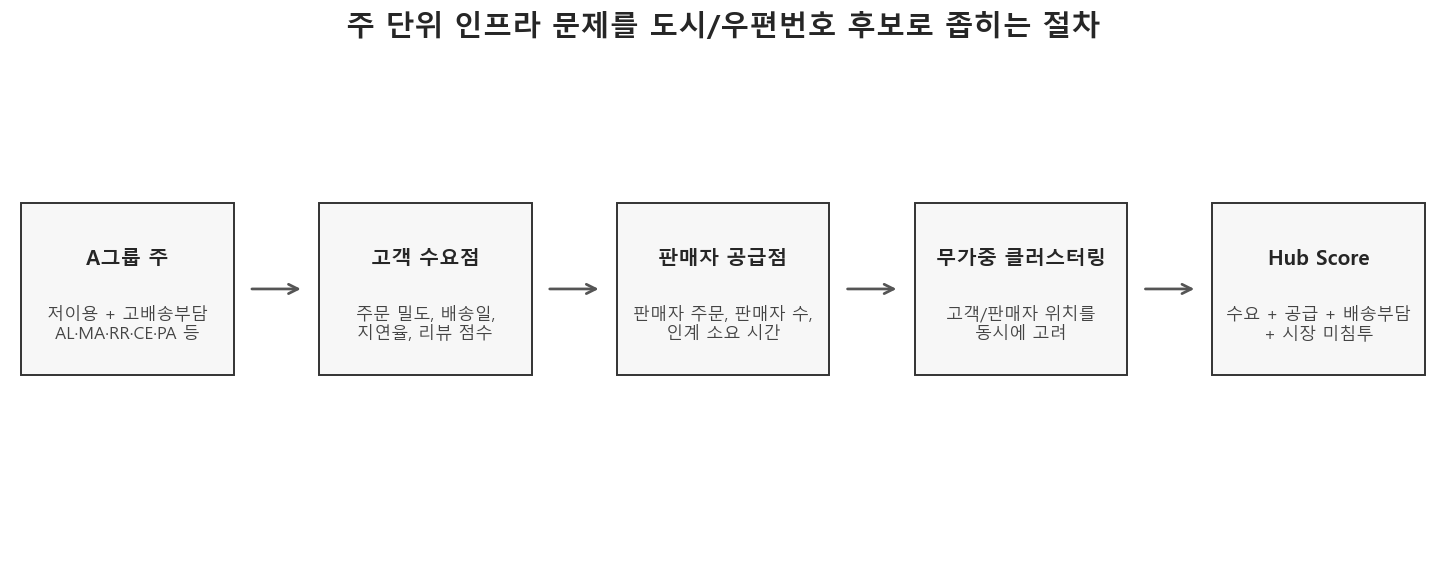

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.axis('off')
items = [
    ('A그룹 주', '저이용 + 고배송부담\nAL·MA·RR·CE·PA 등'),
    ('고객 수요점', '주문 밀도, 배송일,\n지연율, 리뷰 점수'),
    ('판매자 공급점', '판매자 주문, 판매자 수,\n인계 소요 시간'),
    ('무가중 클러스터링', '고객/판매자 위치를\n동시에 고려'),
    ('Hub Score', '수요 + 공급 + 배송부담\n+ 시장 미침투')
]
xs = np.linspace(0.08, 0.92, len(items))
for i, (title, desc) in enumerate(items):
    x = xs[i]
    ax.add_patch(plt.Rectangle((x - 0.075, 0.35), 0.15, 0.34, facecolor='#F7F7F7', edgecolor='#333333'))
    ax.text(x, 0.58, title, ha='center', va='center', fontsize=10.5, weight='bold')
    ax.text(x, 0.45, desc, ha='center', va='center', fontsize=8.8, color='#444444')
    if i < len(items) - 1:
        ax.annotate('', xy=(xs[i+1] - 0.085, 0.52), xytext=(x + 0.085, 0.52), arrowprops=dict(arrowstyle='->', lw=1.4, color='#555555'))
ax.set_title('주 단위 인프라 문제를 도시/우편번호 후보로 좁히는 절차', fontsize=15, weight='bold')
savefig('slide07_state_to_hub_logic.png')
plt.show()

## Slide 8. 최종 후보 주와 후보 도시

**제목 제안**: `13개 공동집하거점 후보 도출`

**넣을 내용**

- 최종 후보는 총 13개이며, CE·MA·PA·AL·RN 등이 상위권에 위치한다.
- CE `caucaia`는 Hub Score 1위이며 고객 수요 커버와 판매자 공급이 함께 관측된다.
- MA `santa rita`는 판매자 공급 점수가 강하고, PA `quatro bocas`는 고객 수요와 시장 격차 측면에서 높다.

**시각화**: 후보별 Hub Score 순위.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide08_hub_score_ranking.png


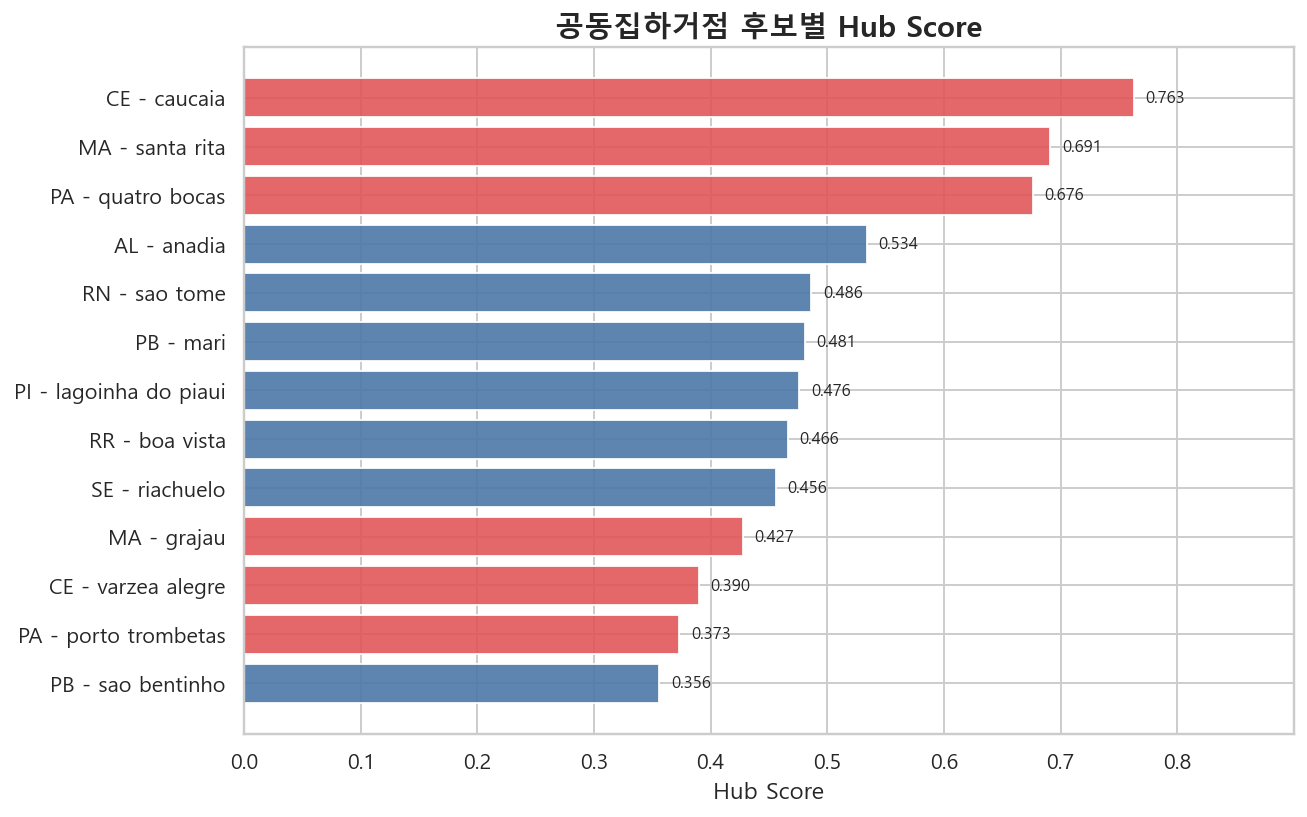

In [9]:
hc = hub_candidates.sort_values('hub_score', ascending=True).copy()
hc['후보'] = hc['state'] + ' - ' + hc['suggested_city']

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = ['#E15759' if s in ['CE', 'MA', 'PA'] else '#4C78A8' for s in hc['state']]
ax.barh(hc['후보'], hc['hub_score'], color=colors, alpha=0.9)
for i, v in enumerate(hc['hub_score']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8.5)
ax.set_title('공동집하거점 후보별 Hub Score', fontsize=15, weight='bold')
ax.set_xlabel('Hub Score')
ax.set_ylabel('')
ax.set_xlim(0, max(hc['hub_score']) * 1.18)
savefig('slide08_hub_score_ranking.png')
plt.show()

## Slide 9. 지도에서 본 후보 거점 위치

**제목 제안**: `후보 거점은 북부·북동부 수요 지점 주변에 배치됨`

**넣을 내용**

- 고객 수요점은 북부·북동부 전역에 퍼져 있지만, 후보 거점은 수요 밀집과 배송 부담을 반영해 대표 위치로 압축된다.
- 이 지도는 배경지도 없이 위도/경도 산점도로 표현한 정적 발표용 시각화다.
- 실제 설치 전에는 도로망 기반 주행시간, 임대료, 처리 가능 물량 검증이 추가로 필요하다.

**시각화**: 고객 수요점과 최종 후보 거점 지도.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide09_candidate_hub_map.png


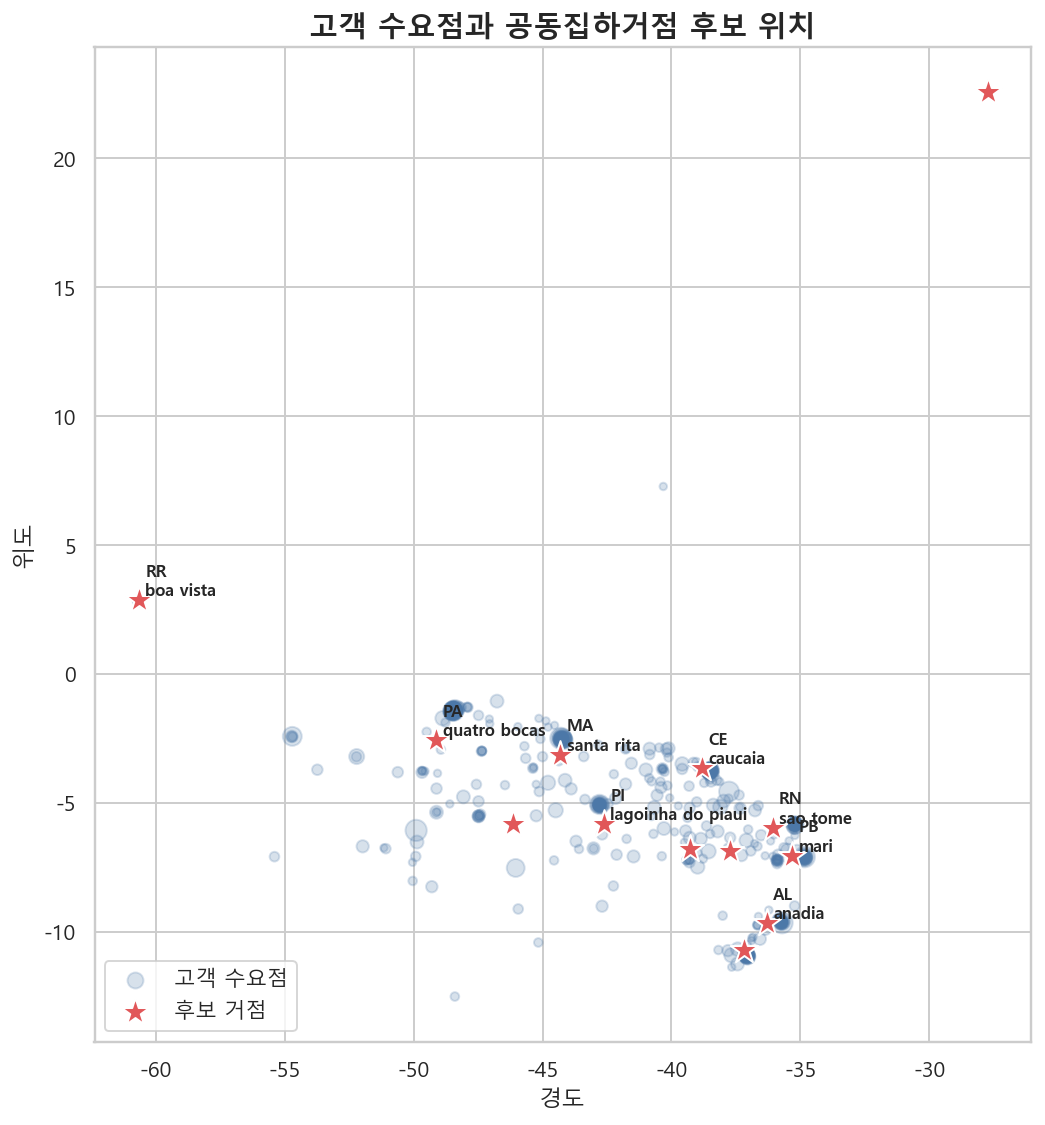

In [10]:
cp = customer_points.copy()
cp['customer_orders'] = pd.to_numeric(cp['customer_orders'], errors='coerce').fillna(0)
sample_cp = cp.sort_values('customer_orders', ascending=False).head(600)
top_label_hubs = hub_candidates.sort_values('hub_score', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(8.2, 8.2))
ax.scatter(sample_cp['lng'], sample_cp['lat'], s=np.clip(sample_cp['customer_orders'] * 5, 8, 120), color='#4C78A8', alpha=0.22, label='고객 수요점')
ax.scatter(hub_candidates['hub_lng'], hub_candidates['hub_lat'], s=220, marker='*', color='#E15759', edgecolor='white', linewidth=1.0, label='후보 거점')
for _, row in top_label_hubs.iterrows():
    ax.text(row['hub_lng'] + 0.25, row['hub_lat'] + 0.18, f"{row['state']}\n{row['suggested_city']}", fontsize=8.5, weight='bold')
ax.set_title('고객 수요점과 공동집하거점 후보 위치', fontsize=15, weight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(loc='lower left')
ax.set_aspect('equal', adjustable='box')
savefig('slide09_candidate_hub_map.png')
plt.show()

## Slide 10. 후보 점수는 무엇으로 구성되는가

**제목 제안**: `상위 후보의 강점은 서로 다르다`

**넣을 내용**

- CE `caucaia`: 고객 수요 커버가 가장 크고 판매자 공급도 일부 존재해 균형이 좋다.
- MA `santa rita`: 판매자 공급 기반이 강하게 반영된다.
- PA `quatro bocas`: 고객 수요와 시장 미침투도는 높지만 현재 커버 판매자 수는 낮아 판매자 확보 전략이 필요하다.
- 즉 같은 “상위 후보”라도 실행 전략은 다르게 설계해야 한다.

**시각화**: 상위 후보별 점수 구성 요소.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide10_hub_score_components.png


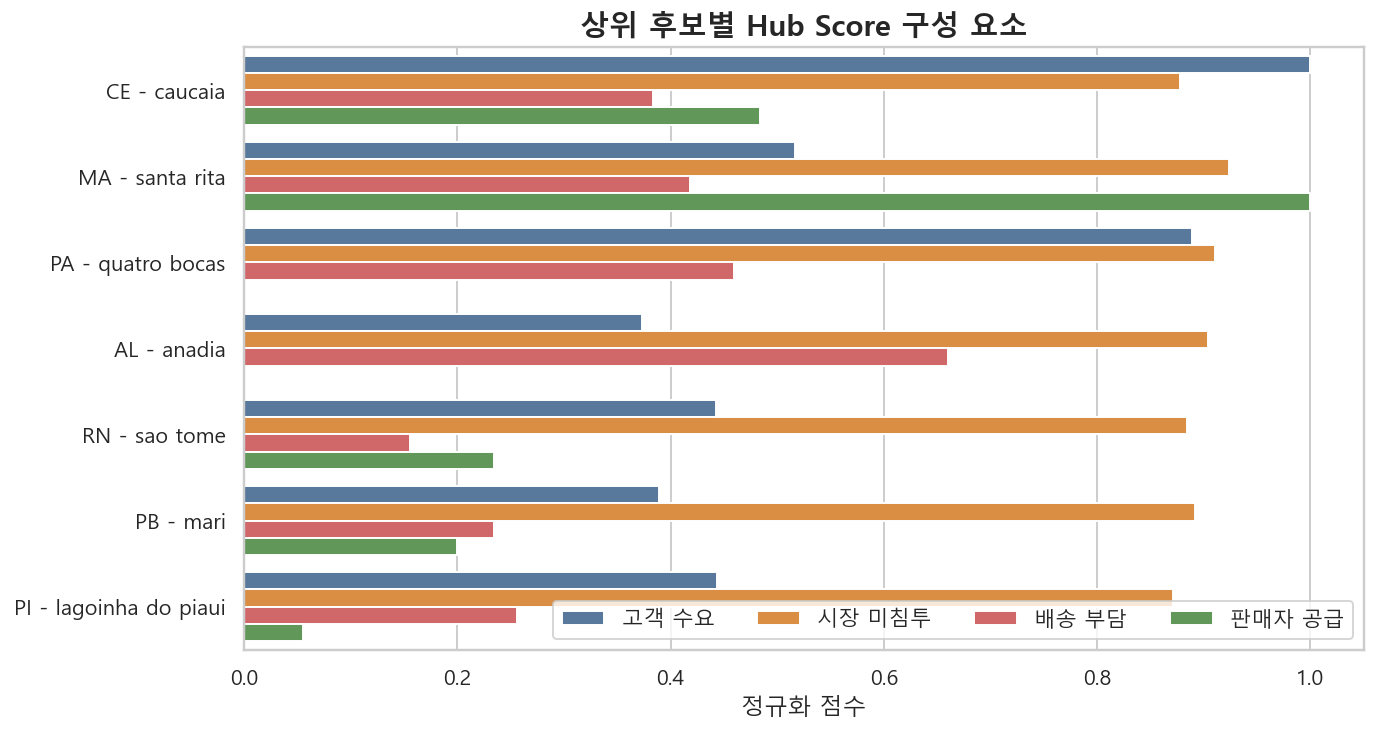

In [11]:
top_hubs = hub_candidates.sort_values('hub_score', ascending=False).head(7).copy()
top_hubs['후보'] = top_hubs['state'] + ' - ' + top_hubs['suggested_city']
component_cols = ['customer_demand_score', 'market_gap_score', 'delivery_burden_score', 'seller_supply_score']
labels = {'customer_demand_score': '고객 수요', 'market_gap_score': '시장 미침투', 'delivery_burden_score': '배송 부담', 'seller_supply_score': '판매자 공급'}
long = top_hubs.melt(id_vars='후보', value_vars=component_cols, var_name='component', value_name='score')
long['component'] = long['component'].map(labels)

fig, ax = plt.subplots(figsize=(10, 5.4))
sns.barplot(data=long, y='후보', x='score', hue='component', palette=['#4C78A8', '#F28E2B', '#E15759', '#59A14F'], ax=ax)
ax.set_title('상위 후보별 Hub Score 구성 요소', fontsize=15, weight='bold')
ax.set_xlabel('정규화 점수')
ax.set_ylabel('')
ax.legend(title='', ncol=4, loc='lower right')
savefig('slide10_hub_score_components.png')
plt.show()

## Slide 11. 결과가 특정 가중치에만 의존하지 않는가

**제목 제안**: `CE·MA·PA는 여러 점수화 방식에서도 상위권 유지`

**넣을 내용**

- 기본 Hub Score 외에도 AHP, Entropy, CRITIC, PCA 방식으로 점수 안정성을 확인했다.
- CE `caucaia`, MA `santa rita`, PA `quatro bocas`는 여러 방식에서 Top5에 반복 포함된다.
- 이는 단일 가중치 하나가 만든 우연한 결과라기보다, 데이터 구조상 반복적으로 드러나는 후보라는 의미다.

**시각화**: 후보별 점수화 방식별 순위 히트맵.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide11_rank_stability.png


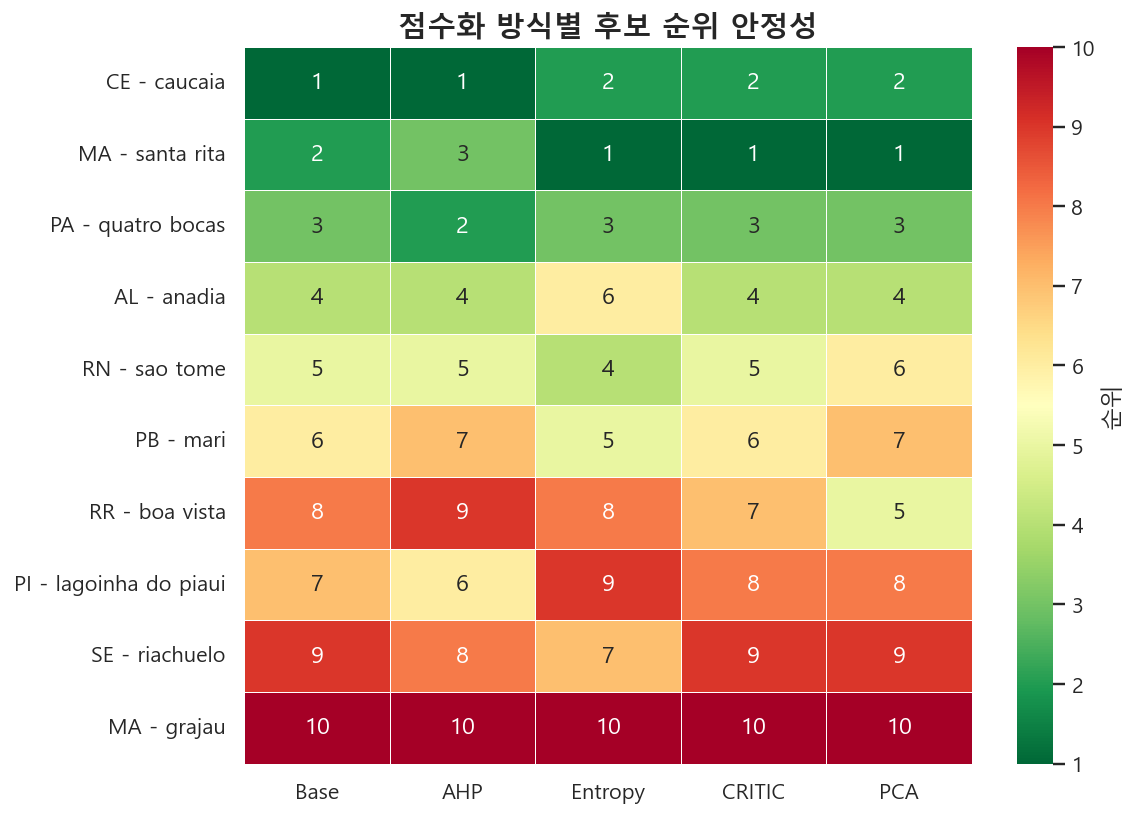

In [12]:
rank_cols = ['rank_base', 'rank_ahp', 'rank_entropy', 'rank_critic', 'rank_pca']
rank_df = hub_candidates.sort_values(['rank_mean', 'rank_std']).head(10).copy()
rank_df['후보'] = rank_df['state'] + ' - ' + rank_df['suggested_city']
heat = rank_df.set_index('후보')[rank_cols]
heat.columns = ['Base', 'AHP', 'Entropy', 'CRITIC', 'PCA']

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='RdYlGn_r', linewidths=0.5, cbar_kws={'label': '순위'}, ax=ax)
ax.set_title('점수화 방식별 후보 순위 안정성', fontsize=15, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
savefig('slide11_rank_stability.png')
plt.show()

## Slide 12. 기대효과는 회복률과 주문 잠재량을 함께 본다

**제목 제안**: `격차 회복 가능성과 시장 규모를 동시에 확인`

**넣을 내용**

- ML 시뮬레이션은 동남부 수준의 물류 조건을 가정했을 때 현재 격차 중 어느 정도를 따라잡을 수 있는지를 보는 보조 근거다.
- 회복률만 보면 RR처럼 현재 규모가 작은 지역도 높게 보일 수 있다.
- 그래서 최종 의사결정에서는 격차회복률과 기대 상승 주문건수를 함께 봐야 한다.
- CE·PA·MA는 Hub Score, 회복 잠재력, 주문 잠재량을 함께 고려할 때 핵심 검토축이다.

**시각화**: 격차회복률과 공격 시나리오 기대 상승 주문건수.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide12_recovery_and_order_uplift.png


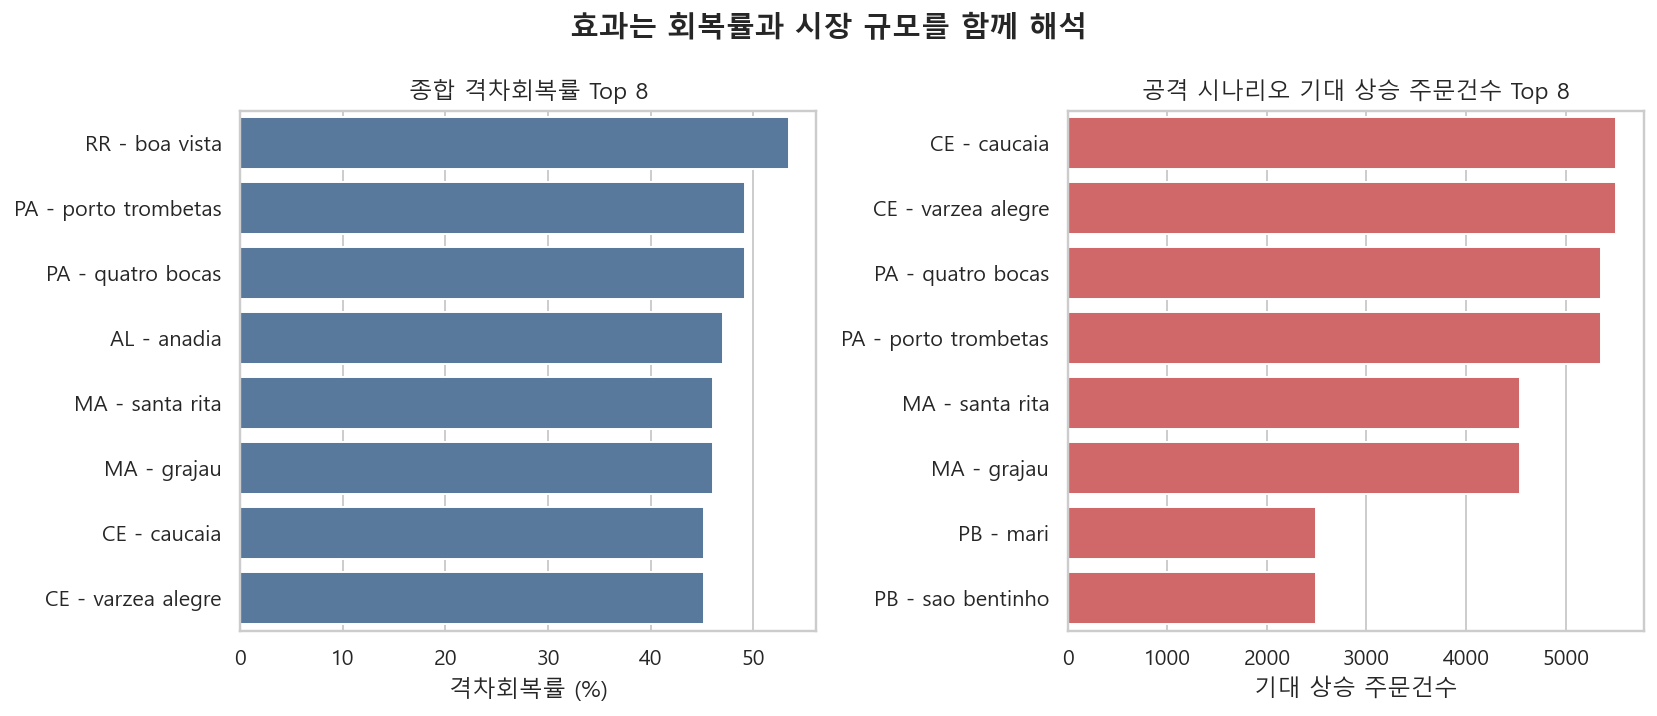

In [13]:
impact = final_recovery.copy()
impact['후보'] = impact['주'] + ' - ' + impact['후보도시']
impact = impact.sort_values('공격_기대상승주문건수', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
left = impact.sort_values('종합_격차회복률_pct', ascending=False).head(8)
sns.barplot(data=left, y='후보', x='종합_격차회복률_pct', color='#4C78A8', ax=axes[0])
axes[0].set_title('종합 격차회복률 Top 8')
axes[0].set_xlabel('격차회복률 (%)')
axes[0].set_ylabel('')

right = impact.head(8)
sns.barplot(data=right, y='후보', x='공격_기대상승주문건수', color='#E15759', ax=axes[1])
axes[1].set_title('공격 시나리오 기대 상승 주문건수 Top 8')
axes[1].set_xlabel('기대 상승 주문건수')
axes[1].set_ylabel('')
fig.suptitle('효과는 회복률과 시장 규모를 함께 해석', fontsize=15, weight='bold')
savefig('slide12_recovery_and_order_uplift.png')
plt.show()

## Slide 13. 기존 물류허브 추정 위치와 비교

**제목 제안**: `신규 설치와 기존망 보완을 구분해야 함`

**넣을 내용**

- `seller_handover_existing_hub_estimates.csv`는 판매자 인계 소요 시간을 이용해 기존 물류망 접근성이 높은 위치를 간접 추정한 결과다.
- CE `caucaia`는 기존 추정 허브와 매우 가까워, 완전 신규 설치보다 기존망 확장/처리능력 보강 전략이 자연스럽다.
- 반대로 일부 후보는 기존 추정 허브와 300km 이상 떨어져 있어 신규 공동집하거점 필요성이 상대적으로 크다.
- 기존 허브 추정은 실제 주소 확인이 아니라 간접 추정이므로, 실사 전 참고 지표로 사용한다.

**시각화**: 기존 추정 허브와 신규 후보 거점 지도, 그리고 연결선.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide13_existing_hub_comparison_map.png


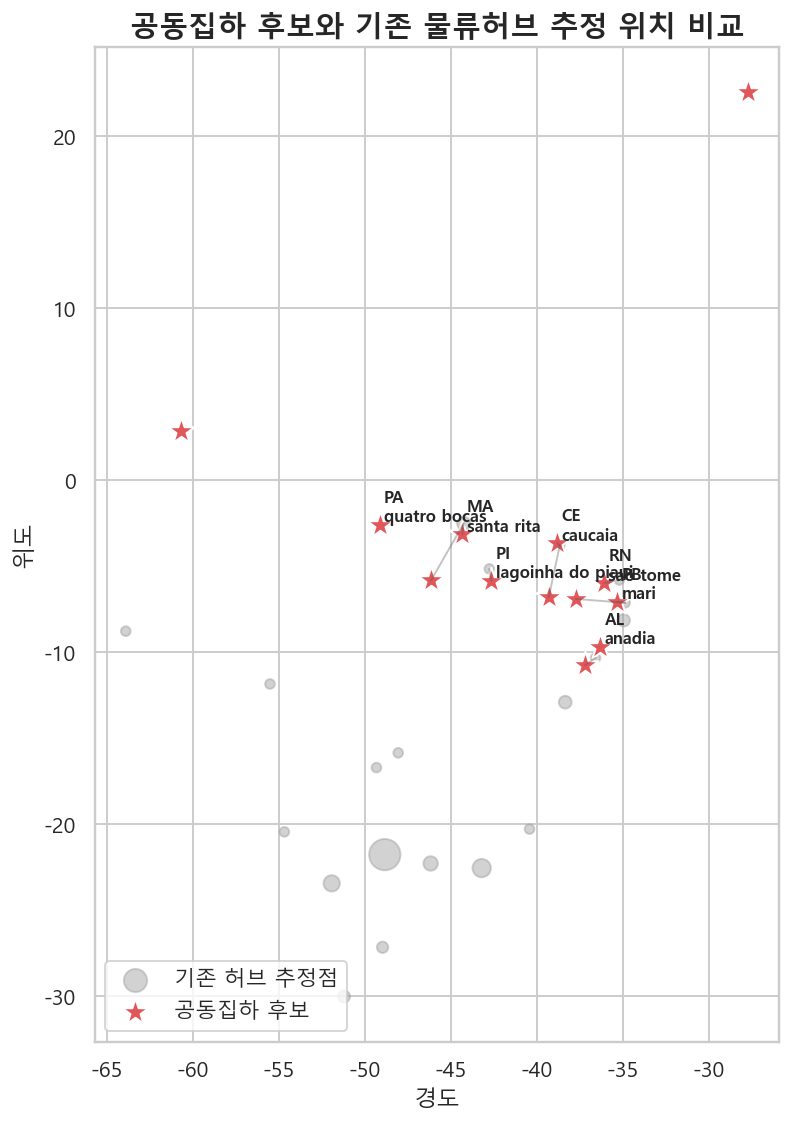

In [14]:
he = hub_existing.copy()
eh = existing_hubs.copy()
for col in ['hub_lat', 'hub_lng', '기존허브추정_위도', '기존허브추정_경도', '기존추정허브와거리_km']:
    he[col] = pd.to_numeric(he[col], errors='coerce')
for col in ['기존허브추정_위도', '기존허브추정_경도', '판매자인계주문수']:
    eh[col] = pd.to_numeric(eh[col], errors='coerce')
paired = he.dropna(subset=['기존허브추정_위도', '기존허브추정_경도']).copy()

fig, ax = plt.subplots(figsize=(8.5, 8.2))
ax.scatter(eh['기존허브추정_경도'], eh['기존허브추정_위도'], s=np.clip(eh['판매자인계주문수'] / 8, 25, 260), color='#9D9D9D', alpha=0.45, label='기존 허브 추정점')
ax.scatter(hub_candidates['hub_lng'], hub_candidates['hub_lat'], s=200, marker='*', color='#E15759', edgecolor='white', linewidth=1.0, label='공동집하 후보')
for _, row in paired.iterrows():
    ax.plot([row['hub_lng'], row['기존허브추정_경도']], [row['hub_lat'], row['기존허브추정_위도']], color='#555555', alpha=0.35, linewidth=1)
for _, row in hub_candidates.sort_values('hub_score', ascending=False).head(7).iterrows():
    ax.text(row['hub_lng'] + 0.25, row['hub_lat'] + 0.18, f"{row['state']}\n{row['suggested_city']}", fontsize=8.5, weight='bold')
ax.set_title('공동집하 후보와 기존 물류허브 추정 위치 비교', fontsize=15, weight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(loc='lower left')
ax.set_aspect('equal', adjustable='box')
savefig('slide13_existing_hub_comparison_map.png')
plt.show()

## Slide 14. 최종 제안: 주와 실행 방식까지 함께 제시

**제목 제안**: `CE·MA·PA 중심의 1차 실사 후보군`

**넣을 내용**

- 최우선 검토: CE `caucaia` - Hub Score 1위, 고객 수요와 판매자 공급이 함께 관측, 기존망 확장 전략 가능.
- 우선 검토: MA `santa rita` - 판매자 공급 기반과 배송 부담이 함께 관측, 기존 허브와 중간 거리.
- 우선 검토: PA `quatro bocas` - 고객 수요/시장 격차가 크고 회복률이 높지만 판매자 확보 전략이 필요.
- 추가 검토: AL, RN, PI, PB 등은 배송 부담 또는 수요 관점에서 후보군으로 유지.
- 다음 단계: 도로망 기반 주행시간, 임대료, 차량 운행비, 인력비, 판매자 밀도, 처리 가능 물량 검증.

**시각화**: 최종 후보 요약 테이블.

saved: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\ppt_figures\slide14_final_candidate_table.png


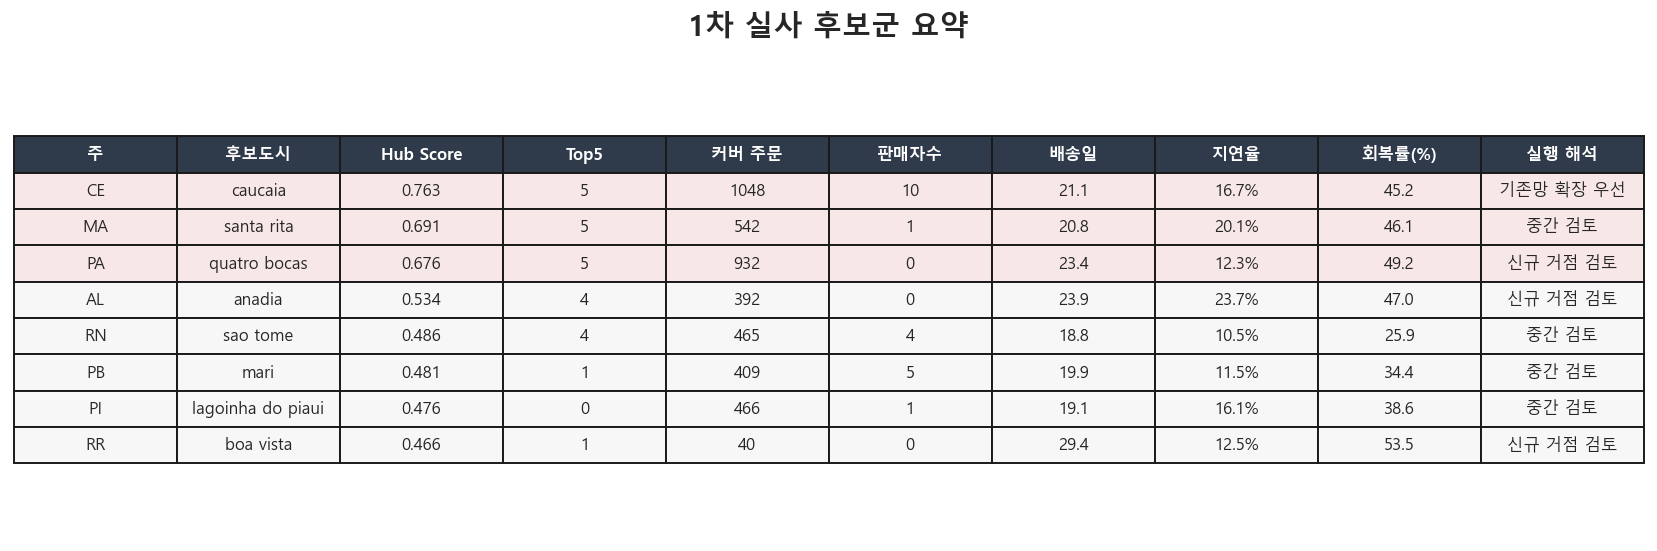

,주,후보도시,Hub Score,Top5,커버 주문,판매자수,배송일,지연율,회복률(%),실행 해석
0,CE,caucaia,0.763,5,1048,10,21.1,16.7%,45.2,기존망 확장 우선
1,MA,santa rita,0.691,5,542,1,20.8,20.1%,46.1,중간 검토
2,PA,quatro bocas,0.676,5,932,0,23.4,12.3%,49.2,신규 거점 검토
3,AL,anadia,0.534,4,392,0,23.9,23.7%,47.0,신규 거점 검토
4,RN,sao tome,0.486,4,465,4,18.8,10.5%,25.9,중간 검토
5,PB,mari,0.481,1,409,5,19.9,11.5%,34.4,중간 검토
6,PI,lagoinha do piaui,0.476,0,466,1,19.1,16.1%,38.6,중간 검토
7,RR,boa vista,0.466,1,40,0,29.4,12.5%,53.5,신규 거점 검토


In [15]:
summary = hub_existing.merge(
    final_recovery[['주', '후보도시', '종합_격차회복률_pct', '공격_기대상승주문건수']],
    left_on=['state', 'suggested_city'], right_on=['주', '후보도시'], how='left', suffixes=('', '_impact')
).sort_values('hub_score', ascending=False).head(8)

table = summary[['state', 'suggested_city', 'hub_score', 'top5_count', 'covered_customer_orders', 'covered_sellers', 'avg_delivery_days', 'late_rate', '종합_격차회복률_pct', '기존허브보완필요도']].copy()
table.columns = ['주', '후보도시', 'Hub Score', 'Top5', '커버 주문', '판매자수', '배송일', '지연율', '회복률(%)', '실행 해석']
table['Hub Score'] = table['Hub Score'].round(3)
table['배송일'] = table['배송일'].round(1)
table['지연율'] = (table['지연율'] * 100).round(1).astype(str) + '%'
table['회복률(%)'] = table['회복률(%)'].round(1)
table['실행 해석'] = table['실행 해석'].fillna('신규 거점 검토')

fig, ax = plt.subplots(figsize=(12, 4.1))
ax.axis('off')
tbl = ax.table(cellText=table.values, colLabels=table.columns, cellLoc='center', colLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.45)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2F3A4A')
        cell.set_text_props(color='white', weight='bold')
    elif r in [1, 2, 3]:
        cell.set_facecolor('#F8E7E7')
    else:
        cell.set_facecolor('#F7F7F7')
ax.set_title('1차 실사 후보군 요약', fontsize=15, weight='bold', pad=14)
savefig('slide14_final_candidate_table.png')
plt.show()
table